# Principles of Effective Data Visualization — Demo Notebook
### Unit 1, Lecture 9 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)



We continue with the **Melbourne Housing Snapshot** dataset used in the last two lectures —
that keeps the notebook self-contained (`melb_data.csv` should sit next to this file) and
lets us focus entirely on *presentation*, since you already know this data's *content*.

Covered here, in the lecture's order:
1. Exploratory vs. Explanatory analysis
2. The three questions every visualization must answer (audience-driven design)
3. Choosing the right chart for the question
4. Eliminating clutter & focusing attention
5. Bitmap vs. vector graphics, and common file formats
6. Lossless vs. lossy compression (why JPEG is bad for charts)
7. Reproducibility, repeatability, and separating content from design

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option("display.max_columns", 20)

df = pd.read_csv("melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

os.makedirs("viz_exports", exist_ok=True)  # every exported file in this demo lands here
print(f"Loaded {len(df)} property sales")
df.head()

Loaded 13580 property sales


,Date,Suburb,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Price,Type_label
0,2017-09-23,Aberfeldie,5,h,S,Rendina,7.5,3040,5,4,...,730,373.0,2014.0,NaN,-37.75950,144.89427,Western Metropolitan,1543,1830000,House
1,2017-09-23,Airport West,3,h,S,Brad,10.4,3042,3,1,...,551,96.0,1950.0,NaN,-37.72739,144.88235,Western Metropolitan,3464,850000,House
2,2017-09-23,Airport West,3,h,S,Harcourts,10.4,3042,3,2,...,593,NaN,NaN,NaN,-37.72057,144.87558,Western Metropolitan,3464,860000,House
3,2017-09-23,Albanvale,3,h,S,Bells,14.0,3021,3,1,...,619,NaN,NaN,NaN,-37.74521,144.76863,Western Metropolitan,1899,565000,House
4,2017-09-23,Albert Park,3,h,VB,Cayzer,3.0,3206,3,2,...,137,125.0,1890.0,NaN,-37.84388,144.95303,Southern Metropolitan,3280,2100000,House


## 1. Exploratory vs. Explanatory Analysis (Ch1)

**Exploratory analysis** is fast, messy, and for the analyst: many quick plots testing many
hypotheses. **Explanatory analysis** is slow, deliberate, and for the audience: one plot,
one message.

Let's do both on the same underlying question: *"How does price vary across Melbourne?"*

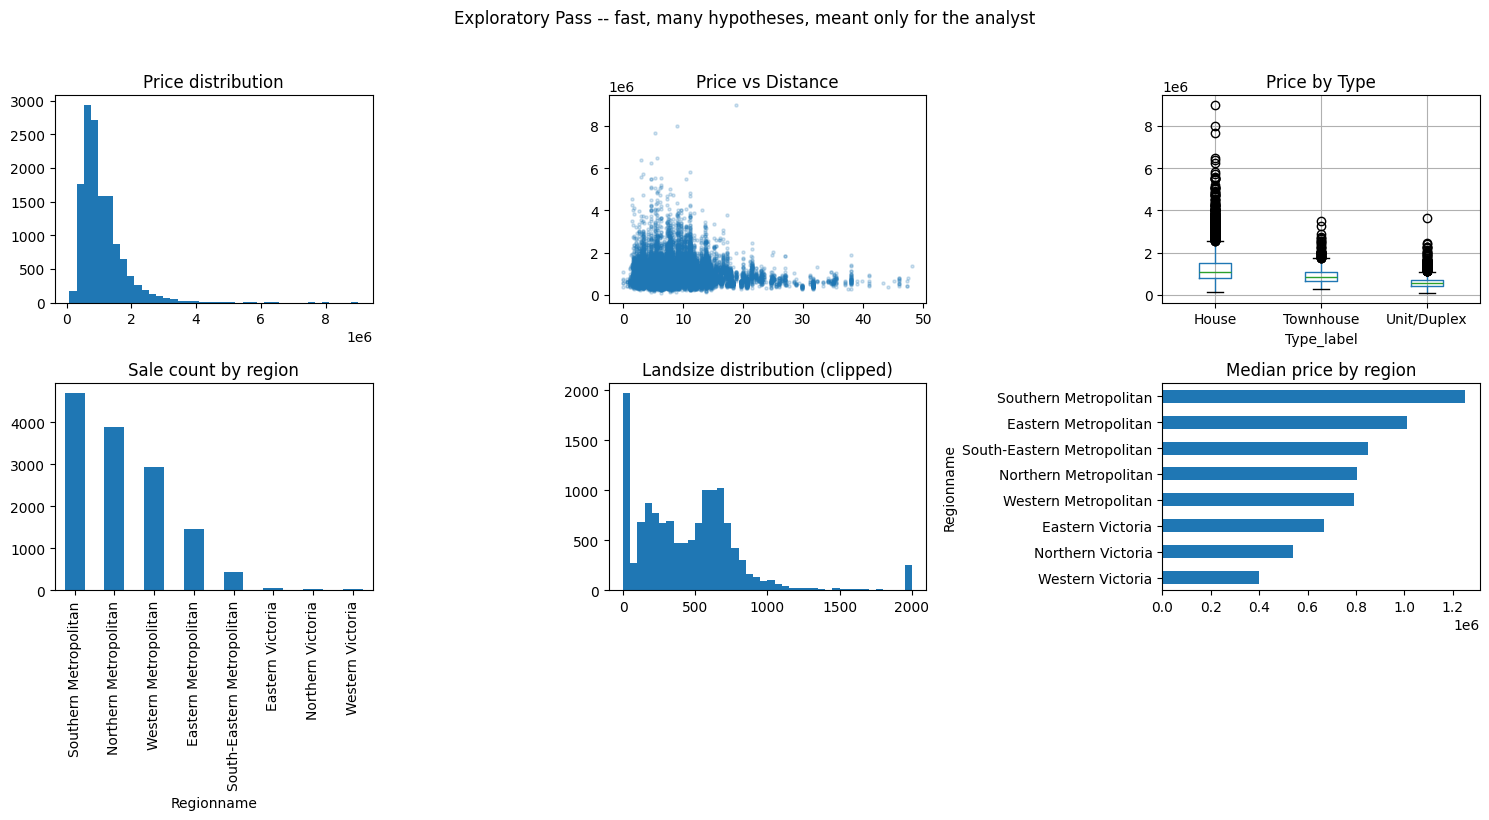

In [ ]:
# --- EXPLORATORY PASS: fast, unpolished, many angles at once ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(df["Price"], bins=40)
axes[0, 0].set_title("Price distribution")

axes[0, 1].scatter(df["Distance"], df["Price"], s=5, alpha=0.2)
axes[0, 1].set_title("Price vs Distance")

df.boxplot(column="Price", by="Type_label", ax=axes[0, 2])
axes[0, 2].set_title("Price by Type")

df["Regionname"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Sale count by region")

axes[1, 1].hist(df["Landsize"].clip(upper=2000), bins=40)
axes[1, 1].set_title("Landsize distribution (clipped)")

df.groupby("Regionname")["Price"].median().sort_values().plot(kind="barh", ax=axes[1, 2])
axes[1, 2].set_title("Median price by region")

plt.suptitle("Exploratory Pass -- fast, many hypotheses, meant only for the analyst", y=1.02)
plt.tight_layout()
plt.show()

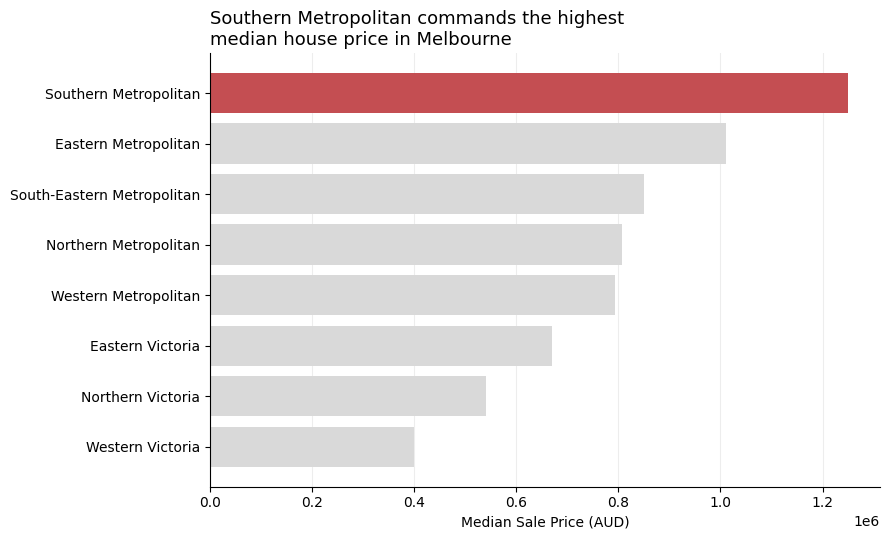

In [ ]:
# --- EXPLANATORY PASS: one plot, one message, designed for an audience ---
region_median = df.groupby("Regionname")["Price"].median().sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#D9D9D9"] * len(region_median)
colors[-1] = "#C44E52"  # highlight only the top region

ax.barh(region_median.index, region_median.values, color=colors)
ax.set_xlabel("Median Sale Price (AUD)")
ax.set_title("Southern Metropolitan commands the highest\nmedian house price in Melbourne", loc="left", fontsize=13)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#EDEDED")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Practical takeaway:** the exploratory grid took thirty seconds to write and is meant
to be thrown away once you've learned from it. The explanatory chart took real design
decisions — sorting, a single highlight color, a title that states the *finding* rather than
the *variable name* — and is the one you'd actually put in a report.

## 2. The Three Questions: Audience-Driven Design (Ch1)

*Who is the audience? What should they know or do? How will you communicate it?*

Same underlying finding — "houses are far more expensive than units" — built two ways:
one for a **fellow analyst** (who wants the full distribution) and one for a
**time-pressed executive** (who wants the headline number and nothing else).

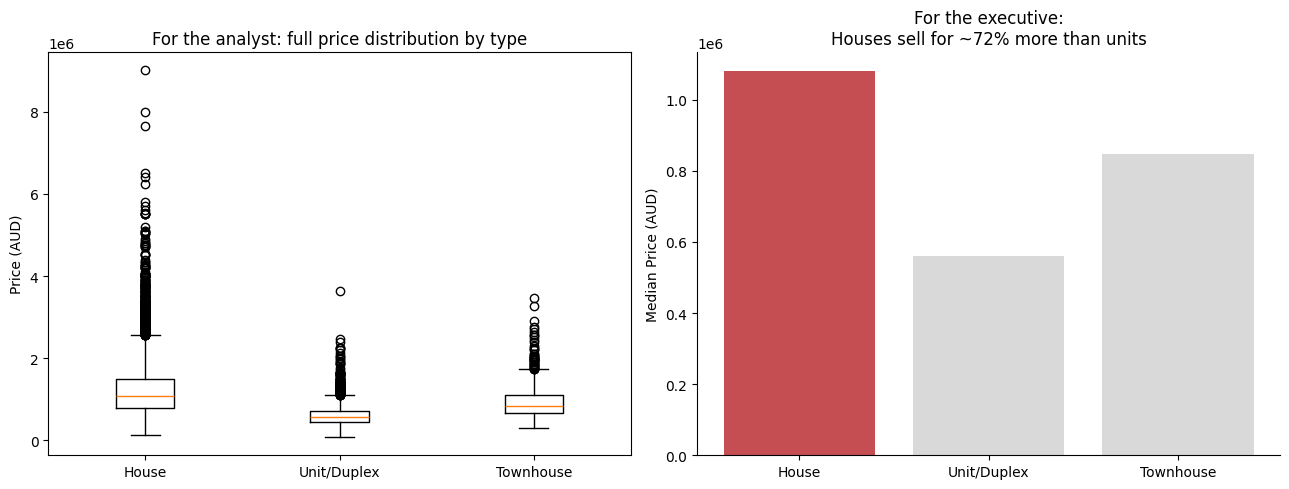

Houses cost 93% more than units at the median.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# For an analyst: full distribution, all detail
sns_data = [df[df["Type_label"] == t]["Price"].dropna() for t in ["House", "Unit/Duplex", "Townhouse"]]
axes[0].boxplot(sns_data, tick_labels=["House", "Unit/Duplex", "Townhouse"])
axes[0].set_title("For the analyst: full price distribution by type")
axes[0].set_ylabel("Price (AUD)")

# For an executive: one headline comparison, annotated
medians = df.groupby("Type_label")["Price"].median().reindex(["House", "Unit/Duplex", "Townhouse"])
colors = ["#C44E52", "#D9D9D9", "#D9D9D9"]
axes[1].bar(medians.index, medians.values, color=colors)
axes[1].set_title("For the executive:\nHouses sell for ~72% more than units")
axes[1].set_ylabel("Median Price (AUD)")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

pct_diff = (medians["House"] / medians["Unit/Duplex"] - 1) * 100
print(f"Houses cost {pct_diff:.0f}% more than units at the median.")

**Practical takeaway:** the analyst panel invites exploration (quartiles, outliers,
whiskers). The executive panel answers one question and gets out of the way — this is what
Knaflic's "3-minute story" and "Big Idea" look like in practice.

## 3. Choosing the Right Chart for the Question (Ch2)

The lecture's recommendation table, demonstrated directly on our data:

| Purpose | Recommended Chart | Shown below with |
|---|---|---|
| Compare categories | Bar Chart | Median price by property type |
| Show trends | Line Chart | Monthly median price |
| Show relationships | Scatter Plot | Price vs Distance |
| Show distributions | Histogram | Price distribution |
| Show proportions | Stacked Bar | Property type share by region |

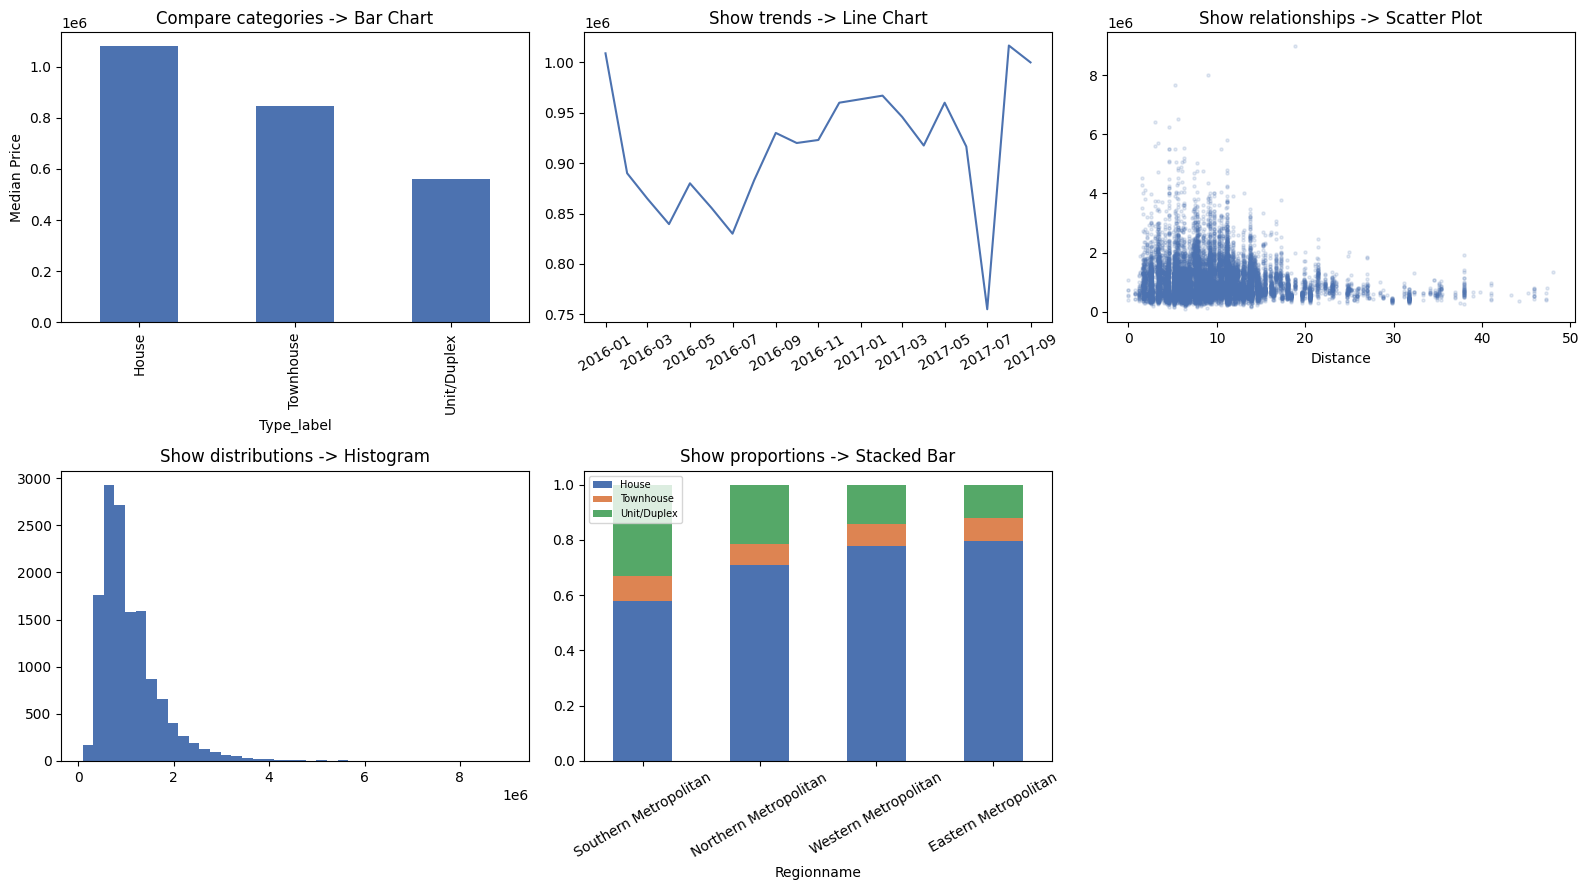

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Compare categories -> Bar
df.groupby("Type_label")["Price"].median().plot(kind="bar", ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Compare categories -> Bar Chart")
axes[0, 0].set_ylabel("Median Price")

# Show trends -> Line
monthly = df.set_index("Date").resample("MS")["Price"].median().interpolate()
axes[0, 1].plot(monthly.index, monthly.values, color="#4C72B0")
axes[0, 1].set_title("Show trends -> Line Chart")
axes[0, 1].tick_params(axis="x", rotation=30)

# Show relationships -> Scatter
axes[0, 2].scatter(df["Distance"], df["Price"], s=5, alpha=0.15, color="#4C72B0")
axes[0, 2].set_title("Show relationships -> Scatter Plot")
axes[0, 2].set_xlabel("Distance")

# Show distributions -> Histogram
axes[1, 0].hist(df["Price"], bins=40, color="#4C72B0")
axes[1, 0].set_title("Show distributions -> Histogram")

# Show proportions -> Stacked bar
prop = pd.crosstab(df["Regionname"], df["Type_label"], normalize="index")
prop = prop.loc[df["Regionname"].value_counts().head(4).index]
prop.plot(kind="bar", stacked=True, ax=axes[1, 1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1, 1].set_title("Show proportions -> Stacked Bar")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].legend(fontsize=7)

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### Why the wrong chart hurts, even with good data

Let's take the *proportions* question — property type share by region — and deliberately
answer it with a chart the lecture warns against: a pie chart with too many wedges.

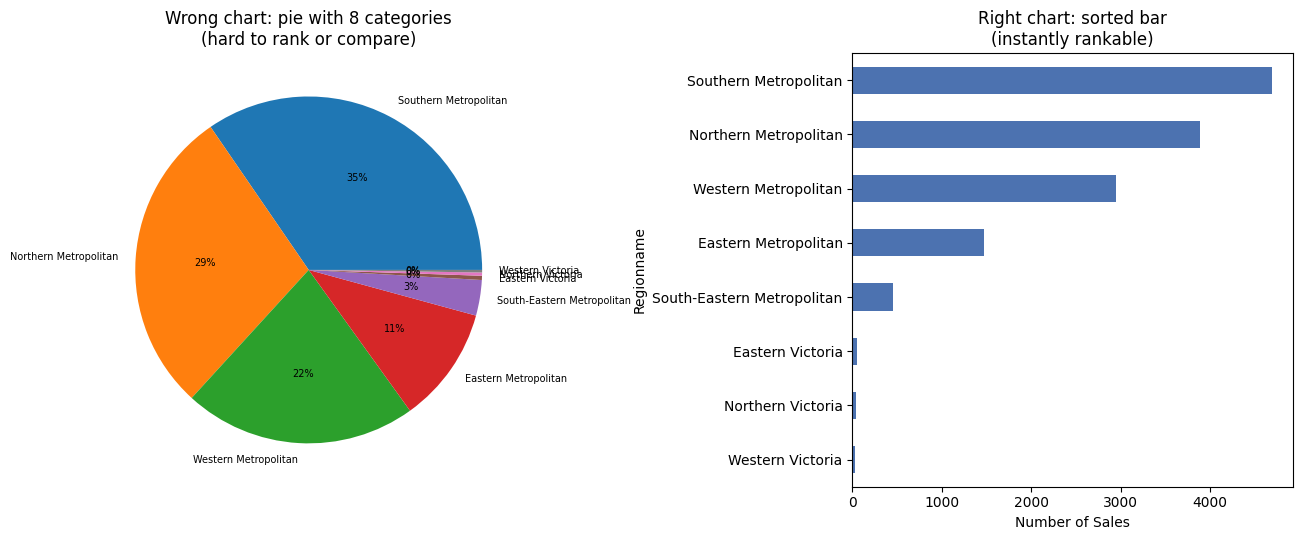

In [ ]:
region_counts = df["Regionname"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].pie(region_counts, labels=region_counts.index, autopct="%1.0f%%", textprops={"fontsize": 7})
axes[0].set_title("Wrong chart: pie with 8 categories\n(hard to rank or compare)")

region_counts.sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Right chart: sorted bar\n(instantly rankable)")
axes[1].set_xlabel("Number of Sales")

plt.tight_layout()
plt.show()

**Practical takeaway:** both charts show the *same numbers*. Only the bar chart lets
you instantly answer "which region has the most sales, and by roughly how much?" — which is
exactly the lecture's point: identify the question first, then pick the chart.

## 4. Eliminating Clutter & Focusing Attention (Ch1)

Same chart, same data — a "before" version with everything the lecture warns against, and
an "after" version with clutter removed and attention directed to one finding.

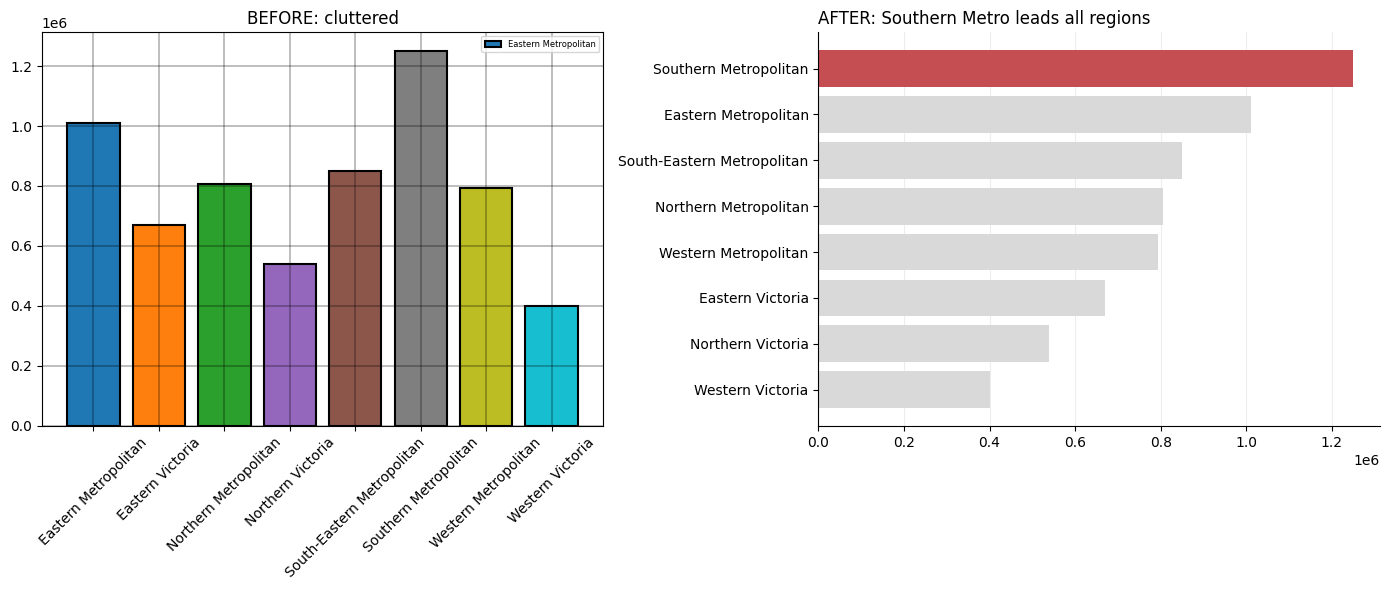

In [ ]:
region_median = df.groupby("Regionname")["Price"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE: cluttered -- unsorted, heavy gridlines, rainbow colors, redundant legend, 3D-style edges
colors_before = plt.cm.tab10(np.linspace(0, 1, len(region_median)))
axes[0].bar(region_median.index, region_median.values, color=colors_before,
            edgecolor="black", linewidth=1.5)
axes[0].set_title("BEFORE: cluttered", fontsize=12)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, linewidth=1.2, color="black", alpha=0.3)
axes[0].legend(region_median.index, fontsize=6, loc="upper right", ncol=2)

# AFTER: sorted, single highlight, minimal gridlines, no redundant legend, direct message in title
sorted_median = region_median.sort_values()
colors_after = ["#D9D9D9"] * len(sorted_median)
colors_after[list(sorted_median.index).index("Southern Metropolitan")] = "#C44E52"
axes[1].barh(sorted_median.index, sorted_median.values, color=colors_after)
axes[1].set_title("AFTER: Southern Metro leads all regions", fontsize=12, loc="left")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)
axes[1].grid(axis="x", color="#EDEDED")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

**Practical takeaway:** nothing about the *underlying numbers* changed between BEFORE
and AFTER. Sorting, one highlight color, and removing the legend/heavy gridlines are the
entire difference — this is "eliminate clutter" and "focus attention" as concrete edits, not
abstract advice.

## 5. Bitmap vs. Vector Graphics, and File Formats (Sec 27.1)

Let's actually save one chart in multiple formats and inspect the real consequences.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sorted_median.index, sorted_median.values, color="#4C72B0")
ax.set_title("Median Price by Region")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()

# Save as a low-resolution bitmap (PNG) and as vector formats (SVG, PDF)
fig.savefig("viz_exports/chart_bitmap_low.png", dpi=40)
fig.savefig("viz_exports/chart_vector.svg")
fig.savefig("viz_exports/chart_vector.pdf")
plt.close(fig)

for f in ["chart_bitmap_low.png", "chart_vector.svg", "chart_vector.pdf"]:
    size_kb = os.path.getsize(f"viz_exports/{f}") / 1024
    print(f"{f:22s} {size_kb:8.1f} KB")

chart_bitmap_low.png       10.2 KB
chart_vector.svg           33.8 KB
chart_vector.pdf           12.7 KB


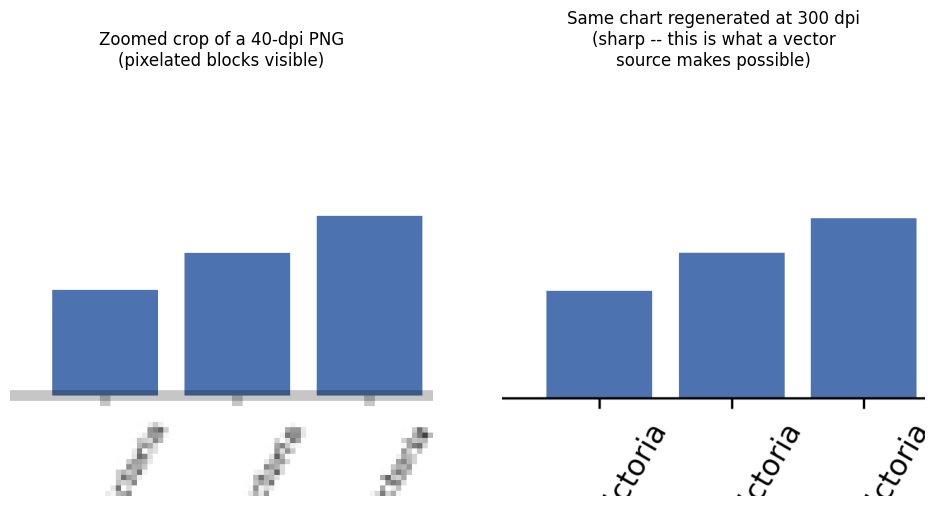

In [ ]:
# Zoom into the low-resolution PNG the way you would zoom into a photo -- it pixelates,
# because a bitmap only stores a fixed grid of pixels.
bitmap_img = Image.open("viz_exports/chart_bitmap_low.png")
crop = bitmap_img.crop((20, 20, 100, 100))
crop_upscaled = crop.resize((400, 400), Image.NEAREST)  # NEAREST reveals the raw pixel blocks

# Re-render the SAME chart directly at high resolution -- this is what a vector source lets
# you do: regenerate crisp output at any size, instead of stretching a fixed pixel grid.
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.bar(sorted_median.index, sorted_median.values, color="#4C72B0")
ax2.set_title("Median Price by Region")
ax2.tick_params(axis="x", rotation=60)
plt.tight_layout()
fig2.savefig("viz_exports/chart_bitmap_high.png", dpi=300)
plt.close(fig2)
high_res_img = Image.open("viz_exports/chart_bitmap_high.png")
crop_high = high_res_img.crop((150, 150, 750, 750))

fig3, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(crop_upscaled)
axes[0].set_title("Zoomed crop of a 40-dpi PNG\n(pixelated blocks visible)")
axes[0].axis("off")
axes[1].imshow(crop_high)
axes[1].set_title("Same chart regenerated at 300 dpi\n(sharp -- this is what a vector\nsource makes possible)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**Practical takeaway:** the 40-dpi PNG is a fixed grid of pixels — zooming in just
makes the *blocks* bigger. A vector-based source (SVG/PDF, or the matplotlib figure object
itself) can be *regenerated* at any resolution because it stores drawing instructions, not
pixels — exactly the "bitmap stores pixels, vector stores instructions" idea from the slide.

**File format cheat sheet from the lecture, applied to what we just made:**
- `chart_vector.pdf` → best for a report or publication (Sec 27.1)
- `chart_vector.svg` → best if this chart were going on a website
- A PNG at a reasonable dpi (150–300) → best for a chart embedded in a slide deck
- We deliberately did **not** save this as a JPEG — see why in the next section.

## 6. Lossless vs. Lossy Compression — Why JPEG Is Bad for Charts (Sec 27.2)

We'll save the *same* chart as PNG (lossless) and as JPEG at several quality levels
(lossy), then compare file size and zoom into a region with text and sharp bar edges.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sorted_median.index, sorted_median.values, color="#4C72B0")
ax.set_title("Median Price by Region")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
fig.savefig("viz_exports/compression_source.png", dpi=150)
plt.close(fig)

source_img = Image.open("viz_exports/compression_source.png").convert("RGB")
source_img.save("viz_exports/compression_lossless.png")  # PNG: lossless
source_img.save("viz_exports/compression_q90.jpg", quality=90)
source_img.save("viz_exports/compression_q30.jpg", quality=30)
source_img.save("viz_exports/compression_q5.jpg", quality=5)

for f in ["compression_lossless.png", "compression_q90.jpg", "compression_q30.jpg", "compression_q5.jpg"]:
    size_kb = os.path.getsize(f"viz_exports/{f}") / 1024
    print(f"{f:28s} {size_kb:8.1f} KB")

compression_lossless.png         62.3 KB
compression_q90.jpg              55.9 KB
compression_q30.jpg              28.3 KB
compression_q5.jpg               16.1 KB


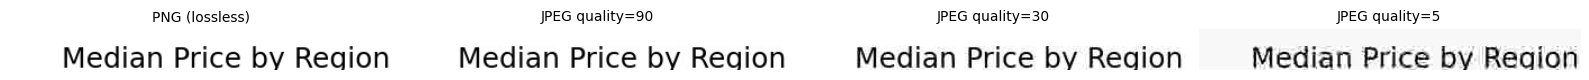

In [ ]:
# Zoom into the region containing the title text -- this is exactly where JPEG artifacts
# (blurry text, ringing around sharp edges) show up worst. The source image is 900x600;
# the title sits centered near the top.
crop_box = (280, 8, 620, 45)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, fname, label in zip(
    axes,
    ["compression_lossless.png", "compression_q90.jpg", "compression_q30.jpg", "compression_q5.jpg"],
    ["PNG (lossless)", "JPEG quality=90", "JPEG quality=30", "JPEG quality=5"],
):
    img = Image.open(f"viz_exports/{fname}")
    crop = img.crop(crop_box).resize((680, 74), Image.NEAREST)  # enlarge so artifacts are visible
    ax.imshow(crop)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Practical takeaway:** the PNG text stays crisp no matter how many times you re-open
and re-save it. The JPEG versions get visibly blurrier and blockier as quality drops — and
this damage is *permanent*: once saved, that detail cannot be recovered, even by re-saving
at a higher quality setting. This is precisely why charts (sharp text, hard edges) belong in
PNG/SVG/PDF, while JPEG is reserved for photographs (smooth gradients hide the artifacts).

## 7. Reproducibility, Repeatability & Separating Content from Design (Sec 28)

**Content** = data, variables, axes, plot type. **Design** = colors, fonts, gridlines,
theme. Changing the theme should never change the underlying message.

We'll wrap our chart in a function — this *is* what reproducibility looks like in practice:
anyone with this code and this data can regenerate an identical figure, and we can restyle
it without touching a single data value.

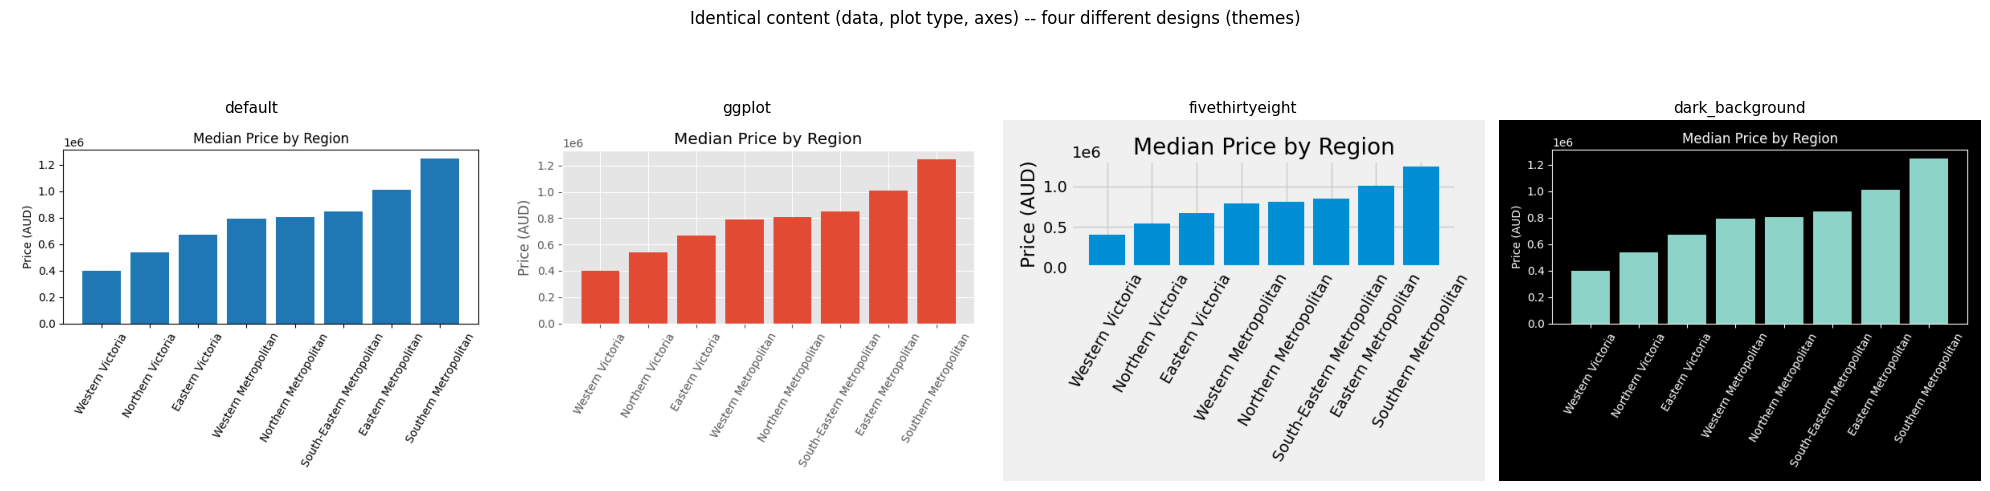

In [ ]:
def make_region_price_chart(theme="default"):
    # Same content every time: median price by region. Only the design (theme) changes.
    with plt.style.context(theme):
        fig, ax = plt.subplots(figsize=(6, 4.5))
        ax.bar(sorted_median.index, sorted_median.values)
        ax.set_title("Median Price by Region")
        ax.set_ylabel("Price (AUD)")
        ax.tick_params(axis="x", rotation=60)
        plt.tight_layout()
        return fig

themes = ["default", "ggplot", "fivethirtyeight", "dark_background"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, theme in enumerate(themes):
    sub_fig = make_region_price_chart(theme)
    sub_fig.canvas.draw()
    img_arr = np.asarray(sub_fig.canvas.buffer_rgba())
    axes[i].imshow(img_arr)
    axes[i].axis("off")
    axes[i].set_title(theme, fontsize=11)
    plt.close(sub_fig)

plt.suptitle("Identical content (data, plot type, axes) -- four different designs (themes)", y=1.05)
plt.tight_layout()
plt.show()

**Practical takeaway:** every panel above shows the exact same numbers, sorted the
same way, in the same chart type — only `theme` changed. That's **reproducibility**
(anyone can re-run `make_region_price_chart(...)` and get the same result) and
**repeatability** (the exact styling can be regenerated on demand) working together, and
it's also a direct demonstration of "changing a theme should not change the data."

This is also why heavy manual editing in an interactive GUI tool is harder to reproduce than
a script like this one: the script *is* the record of every decision that produced the
chart.

## Wrap-up

| Concept | What we demonstrated |
|---|---|
| Exploratory vs. Explanatory | A messy 6-panel grid vs. one polished, sorted, highlighted chart |
| Audience-driven design | Analyst boxplot vs. executive headline bar |
| Choosing the right chart | Bar/Line/Scatter/Histogram/Stacked Bar mapped to their purposes |
| Wrong chart, same data | An 8-category pie vs. a sorted bar |
| Eliminate clutter / focus attention | Before/after edit of one bar chart |
| Bitmap vs. vector | Pixelated low-dpi PNG crop vs. a cleanly regenerated high-dpi version |
| File formats | Exported real `.png`, `.svg`, `.pdf` files with measured sizes |
| Lossless vs. lossy | PNG vs. JPEG at 3 quality levels, with visible artifacts and file sizes |
| Reproducibility & content/design | One function, four themes, identical underlying data |



In [1]:
from google.colab import files

uploaded = files.upload()